Note: to run this noteboook, download the CCDC Python CSD and create the dedicated conda environment as follows:
```bash
conda create -n ccdc-env
conda activate ccdc-env
conda install --channel=https://conda.ccdc.cam.ac.uk csd-python-api
conda install ipykernel
```

In [6]:
from ccdc.conformer import MoleculeMinimiser, ConformerGenerator
from ccdc.io import MoleculeWriter
from ccdc import io

from utils.visualize import visualise_mol, visualise_conformers

In [7]:
# Read from CSD
reader = io.EntryReader("CSD")
mol = reader.entry("EMIQOI").molecule
big = max(mol.components, key=lambda c: len(list(c.atoms)))
mol = big

# Find the minimized structure
minimiser = MoleculeMinimiser()
minimised_mol = minimiser.minimise(mol)

visualise_mol(mol, minimised_mol)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

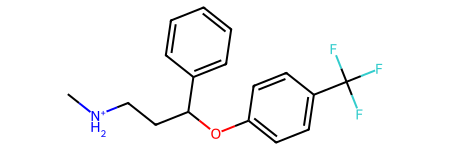

In [8]:
from rdkit import Chem

smiles = mol.smiles
mol = Chem.MolFromSmiles(smiles)
mol


In [12]:
# Testing a pipeline for generating SDF files to be processed by PsiRESP

from ccdc.conformer import MoleculeMinimiser
from ccdc.io import MoleculeWriter
from ccdc import io

# Read from CSD
reader = io.EntryReader("CSD")
mol = reader.entry("EMIQOI").molecule

# Get only the largest component (drug molecule, not counterion)
big = max(mol.components, key=lambda c: len(list(c.atoms)))
mol = big

In [ ]:
from utils.molecule_processing import neutralize_atoms

C[NH2+]CCC(Oc1ccc(cc1)C(F)(F)F)c1ccccc1


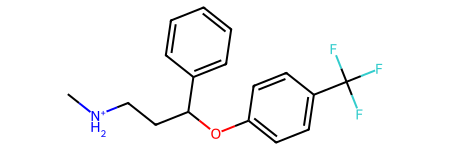

In [ ]:
# Convert to RDKit Mol for neutralisation
rdkit_mol = Chem.MolFromSmiles(big.smiles)
print(big.smiles) 
rdkit_mol

[H]c1c([H])c([H])c(C([H])(Oc2c([H])c([H])c(C(F)(F)F)c([H])c2[H])C([H])([H])C([H])([H])N([H])C([H])([H])[H])c([H])c1[H]


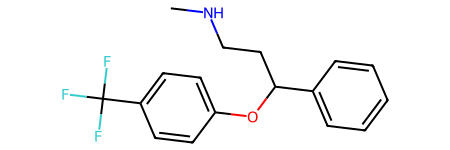

In [ ]:
# Neutralise the molecule
rdkit_mol = neutralize_atoms(rdkit_mol)
smiles = Chem.MolToSmiles(rdkit_mol)
print(smiles) 
rdkit_mol = Chem.MolFromSmiles(smiles)
rdkit_mol

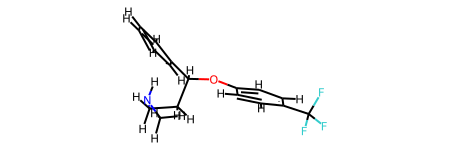

In [ ]:
from rdkit.Chem import AllChem

rdkit_mol = Chem.MolFromSmiles(smiles)
rdkit_mol = Chem.AddHs(rdkit_mol)                     # explicit Hs for good geometry
AllChem.EmbedMolecule(rdkit_mol, randomSeed=42)      # create 3D conformer
AllChem.UFFOptimizeMolecule(rdkit_mol)
rdkit_mol

In [ ]:

from rdkit import Chem
from ccdc import molecule

# Convert back to a CSD API Molecule object
sdf_string = Chem.MolToMolBlock(rdkit_mol)  # Convert to SDF string
ccdc_mol = molecule.Molecule.from_string(sdf_string, format='sdf')

# Minimize
minimiser = MoleculeMinimiser()
minimised_mol = minimiser.minimise(ccdc_mol)

# Save only the drug molecule
filepath = "csd_mol.sdf"
with io.MoleculeWriter(filepath) as mol_writer:
    mol_writer.write(minimised_mol)

print(f"Wrote molecule with {len(list(minimised_mol.atoms))} atoms (counterions excluded)")

Wrote molecule with 40 atoms (counterions excluded)


In [ ]:
ccdc_mol.smiles

'[C][N][C][C][C](OC1=[C][C]=C([C]=[C]1)C(F)(F)F)C1=[C][C]=[C][C]=[C]1'

In [ ]:
from openbabel import pybel
ob = pybel.ob

ModuleNotFoundError: No module named 'openbabel'